## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

sns.set_style("whitegrid")
pd.set_option('display.max_colwidth', 80)

## 2. Load parsed Appendix C

In [2]:
df = pd.read_csv('appendix_c_parsed.csv', low_memory=False)
print(f"Total rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")

print(f"\n'Thank you' replies:    {df['response_is_thank_you'].sum()} ({df['response_is_thank_you'].mean()*100:.1f}%)")
print(f"'See response' replies: {df['response_is_reference'].sum()} ({df['response_is_reference'].mean()*100:.1f}%)")
print(f"Other (substantive):    {(~df['response_is_thank_you'] & ~df['response_is_reference']).sum()}")

Total rows: 3,288
Columns: ['comment_id', 'submitter', 'docket_id', 'comment_text', 'response_text', 'prefix', 'round', 'commenter_type', 'comment_length', 'response_length', 'response_is_thank_you', 'response_is_reference']

'Thank you' replies:    2740 (83.3%)
'See response' replies: 335 (10.2%)
Other (substantive):    213


## 3. Topic schema from FEIS Table 3 (Page 8 of Appendix C)

Agency's 27 official topic categories, organised under 3 common categories:
- **NEPA Process** (7 topics)
- **General Opinion** (4 topics)
- **Analysis** (16 environmental topics)

In [3]:
TOPIC_KEYWORDS = {
    'Climate change':                     [r'\bclimate change\b', r'\bclimate impact', r'\bclimate crisis'],
    'Greenhouse gas emissions':           [r'\bgreenhouse gas', r'\bGHG\b', r'\bcarbon emission'],
    'Marine ecosystems':                  [r'\bmarine ecosystem', r'\bmarine mammal', r'\bmarine wildlife',
                                            r'\bmarine habitat', r'\bmarine and coastal', r'\bwhale', r'\bdolphin'],
    'Wildlife':                           [r'\bwildlife', r'\bmigratory bird', r'\bavian'],
    'Threatened and endangered species':  [r'\bendangered', r'\bthreatened species', r'\bsea turtle',
                                            r'\bBlack Rail', r"\bKemp's Ridley"],
    'Air quality':                        [r'\bair qualit', r'\bair pollution'],
    'Oil spills':                         [r'\boil spill', r'\bspill response', r'\bspill risk',
                                            r'\bDeepwater Horizon', r'\baccidental spill'],
    'Environmental justice':              [r'\benvironmental justice', r'\bEJ communit',
                                            r'\bminority community', r'\bdisadvantaged'],
    'Wetlands':                           [r'\bwetland'],
    'Cultural resources':                 [r'\bcultural resource', r'\bhistoric properties', r'\barchaeolog'],
    'Severe weather':                     [r'\bsevere weather', r'\bhurricane', r'\bstorm surge'],
    'Commercial fishing and tourism':     [r'\bcommercial fish', r'\btourism', r'\bfisheries'],
    'Socioeconomics':                     [r'\bsocioeconom'],
    'Visual resources':                   [r'\bvisual resource', r'\baesthetic', r'\bviewshed'],
    'Utilities':                          [r'\butilit'],
    'Lightering':                         [r'\blightering'],
    # ─── General Opinion (4 topics) ───
    'Project not in national interest':   [r'\bnational interest', r'\bpublic interest'],
    'Opposition':                         [r'\boppos', r'\bstop this', r'\bdeny'],
    'Support of project':                 [r'\bin favor', r'\bsupport.*project'],
    # ─── NEPA Process (7 topics) ───
    'Purpose and need':                   [r'\bpurpose and need'],
    'Alternatives':                       [r'\balternatives analysis', r'\balternative.*considered'],
    'Public participation':               [r'\bpublic participation', r'\bpublic hearing', r'\bpublic meeting'],
    'Financial viability':                [r'\bfinancial viabilit', r'\bfinancial assurance'],
    'Tribal consultation':                [r'\btribal consultation', r'\btribe'],
    'Application area':                   [r'\bapplication area'],
    'Statutory schedule':                 [r'\bstatutory schedule', r'\breview timeline'],
}

TOPIC_TO_CATEGORY = {
    'Climate change': 'Analysis', 'Greenhouse gas emissions': 'Analysis',
    'Marine ecosystems': 'Analysis', 'Wildlife': 'Analysis',
    'Threatened and endangered species': 'Analysis', 'Air quality': 'Analysis',
    'Oil spills': 'Analysis', 'Environmental justice': 'Analysis',
    'Wetlands': 'Analysis', 'Cultural resources': 'Analysis',
    'Severe weather': 'Analysis', 'Commercial fishing and tourism': 'Analysis',
    'Socioeconomics': 'Analysis', 'Visual resources': 'Analysis',
    'Utilities': 'Analysis', 'Lightering': 'Analysis',
    'Project not in national interest': 'General Opinion',
    'Opposition': 'General Opinion', 'Support of project': 'General Opinion',
    'Purpose and need': 'NEPA Process', 'Alternatives': 'NEPA Process',
    'Public participation': 'NEPA Process', 'Financial viability': 'NEPA Process',
    'Tribal consultation': 'NEPA Process', 'Application area': 'NEPA Process',
    'Statutory schedule': 'NEPA Process',
}

print(f"Total topics: {len(TOPIC_KEYWORDS)}")

Total topics: 26


## 4. Apply keyword matching


In [4]:
def extract_topics(text):
    if not isinstance(text, str):
        return []
    matched = []
    for topic, patterns in TOPIC_KEYWORDS.items():
        if any(re.search(p, text, re.IGNORECASE) for p in patterns):
            matched.append(topic)
    return matched

df['topics_from_response'] = df['response_text'].apply(extract_topics)
df['topics_from_comment']  = df['comment_text'].apply(extract_topics)

# Union (response keywords take priority )
df['topics_all'] = df.apply(
    lambda r: list(dict.fromkeys(r['topics_from_response'] + r['topics_from_comment'])),
    axis=1
)
df['n_topics']      = df['topics_all'].str.len()
df['primary_topic'] = df['topics_all'].apply(lambda x: x[0] if x else None)
df['common_category'] = df['primary_topic'].map(TOPIC_TO_CATEGORY)

print(f"Comments with topic from RESPONSE only: {(df['topics_from_response'].str.len() > 0).sum()}")
print(f"Comments with topic from COMMENT only:  {(df['topics_from_comment'].str.len() > 0).sum()}")
print(f"Comments with topic (union):            {(df['n_topics'] > 0).sum()} ({(df['n_topics']>0).mean()*100:.1f}%)")

Comments with topic from RESPONSE only: 1261
Comments with topic from COMMENT only:  1611
Comments with topic (union):            1967 (59.8%)


## 5. Label distribution

In [5]:
topic_counts = df['primary_topic'].value_counts(dropna=False)
print("Primary topic distribution:")
print(topic_counts.to_string())
print()
print("Common category distribution:")
print(df['common_category'].value_counts(dropna=False).to_string())

Primary topic distribution:
primary_topic
None                                 1321
Climate change                        472
Project not in national interest      290
Oil spills                            244
Opposition                            179
Wildlife                              145
Air quality                           122
Marine ecosystems                      80
Commercial fishing and tourism         45
Severe weather                         43
Support of project                     42
Environmental justice                  42
Threatened and endangered species      39
Wetlands                               37
Public participation                   35
Greenhouse gas emissions               34
Purpose and need                       29
Socioeconomics                         28
Lightering                             18
Cultural resources                     12
Tribal consultation                     9
Alternatives                            9
Application area                  

## 6. Validate against Table 3

In [6]:
r1 = df[df['round'] == 'Round1']
print(f"Round 1 rows in our data: {len(r1)}")
print(f"Round 1 rows with topic:  {(r1['n_topics'] > 0).sum()}")
print()
print("Our reverse-engineered counts vs Table 3:")
print()
cat_counts = r1['common_category'].value_counts()
table3_expected = {'NEPA Process': 120, 'General Opinion': 115, 'Analysis': 424}

for cat, expected in table3_expected.items():
    ours = cat_counts.get(cat, 0)
    pct = (ours / expected * 100) if expected else 0
    print(f"  {cat:20s}  ours: {ours:3d}   Table 3: {expected:3d}   recall: {pct:.0f}%")

Round 1 rows in our data: 682
Round 1 rows with topic:  495

Our reverse-engineered counts vs Table 3:

  NEPA Process          ours:  34   Table 3: 120   recall: 28%
  General Opinion       ours:  83   Table 3: 115   recall: 72%
  Analysis              ours: 378   Table 3: 424   recall: 89%


## 7. Export labelled ground-truth dataset

In [7]:
# Keep only rows with at least one topic = labelled set
labelled = df[df['n_topics'] > 0].copy()
print(f"Labelled rows: {len(labelled):,}")

df.to_csv('appendix_c_with_topics.csv', index=False)
labelled.to_csv('appendix_c_labelled.csv', index=False)
print("Saved: appendix_c_with_topics.csv (all 3,288 rows)")
print("Saved: appendix_c_labelled.csv (labelled subset for training)")

Labelled rows: 1,967
Saved: appendix_c_with_topics.csv (all 3,288 rows)
Saved: appendix_c_labelled.csv (labelled subset for training)


## 8. NLP baseline 

In [8]:
data = labelled[['comment_text', 'primary_topic']].dropna().copy()
print(f"Training set size: {len(data):,}")

# Drop very rare topics 
topic_counts = data['primary_topic'].value_counts()
keep_topics = topic_counts[topic_counts >= 10].index
data = data[data['primary_topic'].isin(keep_topics)]
print(f"After dropping rare topics: {len(data):,}")
print(f"Topics kept: {len(keep_topics)}")
print()
print(data['primary_topic'].value_counts())

Training set size: 1,967
After dropping rare topics: 1,936
Topics kept: 19

primary_topic
Climate change                       472
Project not in national interest     290
Oil spills                           244
Opposition                           179
Wildlife                             145
Air quality                          122
Marine ecosystems                     80
Commercial fishing and tourism        45
Severe weather                        43
Support of project                    42
Environmental justice                 42
Threatened and endangered species     39
Wetlands                              37
Public participation                  35
Greenhouse gas emissions              34
Purpose and need                      29
Socioeconomics                        28
Lightering                            18
Cultural resources                    12
Name: count, dtype: int64


In [9]:
X = data['comment_text'].values
y = data['primary_topic'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

Train: 1548  |  Test: 388


In [10]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    stop_words='english',
    min_df=2,
)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)
print(f"TF-IDF feature matrix: {X_train_vec.shape}")

TF-IDF feature matrix: (1548, 10000)


In [11]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, n_jobs=-1),
    'Linear SVM':          LinearSVC(C=1.0),
    'Multinomial NB':      MultinomialNB(),
}

results = {}
for name, model in models.items():
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    results[name] = {'accuracy': acc, 'macro_f1': f1_macro, 'weighted_f1': f1_weighted,
                     'model': model, 'pred': y_pred}
    print(f"{name:25s}  acc={acc:.3f}  macro_f1={f1_macro:.3f}  weighted_f1={f1_weighted:.3f}")

Logistic Regression        acc=0.601  macro_f1=0.276  weighted_f1=0.539
Linear SVM                 acc=0.657  macro_f1=0.466  weighted_f1=0.634
Multinomial NB             acc=0.459  macro_f1=0.156  weighted_f1=0.385


## 9. Detailed per-class report (best model)

In [12]:
best_name = max(results, key=lambda k: results[k]['macro_f1'])
print(f"Best model: {best_name}\n")

y_pred = results[best_name]['pred']
print(classification_report(y_test, y_pred, zero_division=0))

Best model: Linear SVM

                                   precision    recall  f1-score   support

                      Air quality       0.54      0.79      0.64        24
                   Climate change       0.69      0.73      0.71        95
   Commercial fishing and tourism       1.00      0.22      0.36         9
               Cultural resources       0.00      0.00      0.00         2
            Environmental justice       0.40      0.25      0.31         8
         Greenhouse gas emissions       0.50      0.14      0.22         7
                       Lightering       0.00      0.00      0.00         4
                Marine ecosystems       0.75      0.56      0.64        16
                       Oil spills       0.62      0.92      0.74        49
                       Opposition       0.67      0.72      0.69        36
 Project not in national interest       0.74      0.72      0.73        58
             Public participation       0.67      0.86      0.75         7


## 10. Confusion matrix

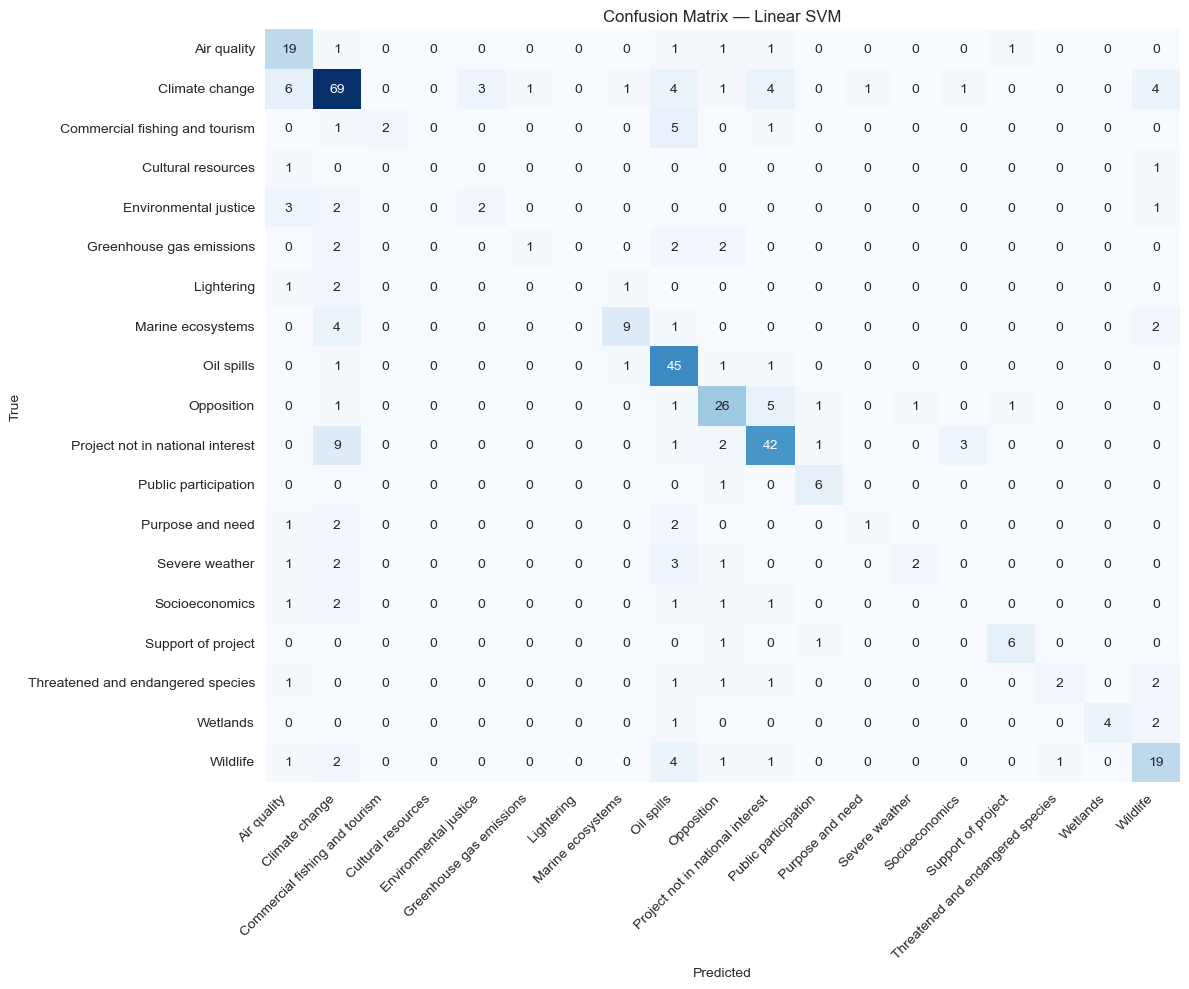

In [13]:
labels = sorted(set(y_test) | set(y_pred))
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax, cbar=False)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix — {best_name}')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=110, bbox_inches='tight')
plt.show()

## 11. Top features per topic


In [14]:
if 'Logistic Regression' in results:
    lr = results['Logistic Regression']['model']
    feature_names = vectorizer.get_feature_names_out()
    
    print("Top 8 words per topic (highest LR coefficients):\n")
    for i, topic in enumerate(lr.classes_):
        top_idx = lr.coef_[i].argsort()[-8:][::-1]
        top_words = [feature_names[j] for j in top_idx]
        print(f"  {topic:40s}  →  {', '.join(top_words)}")

Top 8 words per topic (highest LR coefficients):

  Air quality                               →  air, pollution, quality, air quality, air pollution, communities, impacts, ozone
  Climate change                            →  climate, climate change, change, crisis, emissions, climate crisis, terminals, global
  Commercial fishing and tourism            →  tourism, fishing, recreation, fishing tourism, economy, recreation tourism, shrimp, commercial
  Cultural resources                        →  recognized, tribes, native, tribal, pipelines, land, nagpra, nations
  Environmental justice                     →  health, environmental justice, justice, populations, lep, environmental, block, health impacts
  Greenhouse gas emissions                  →  greenhouse, emissions, greenhouse gas, gas emissions, gas, gases, project, energy
  Lightering                                →  lightering, reverse lightering, reverse, support, reduce, vessel, traffic, port
  Marine ecosystems              

## 12. Predict topics for unlabelled comments

In [15]:
unlabelled = df[df['n_topics'] == 0].copy()
print(f"Unlabelled comments to predict: {len(unlabelled)}")

if len(unlabelled) > 0:
    best_model = results[best_name]['model']
    X_unlab = vectorizer.transform(unlabelled['comment_text'].fillna(''))
    unlabelled['predicted_topic'] = best_model.predict(X_unlab)
    
    print("\nPredicted topic distribution for previously unlabelled:")
    print(unlabelled['predicted_topic'].value_counts().to_string())
    
    df['final_topic'] = df['primary_topic'].fillna(
        df.index.to_series().map(unlabelled['predicted_topic'])
    )
    df.to_csv('appendix_c_final_labels.csv', index=False)
    print(f"\nSaved appendix_c_final_labels.csv with {df['final_topic'].notna().sum()} labelled rows")

Unlabelled comments to predict: 1321

Predicted topic distribution for previously unlabelled:
predicted_topic
Opposition                           399
Climate change                       382
Oil spills                           192
Project not in national interest      98
Air quality                           55
Wildlife                              52
Public participation                  40
Support of project                    29
Commercial fishing and tourism        15
Marine ecosystems                     14
Severe weather                         8
Socioeconomics                         7
Wetlands                               6
Environmental justice                  6
Threatened and endangered species      5
Greenhouse gas emissions               4
Cultural resources                     3
Purpose and need                       3
Lightering                             3

Saved appendix_c_final_labels.csv with 3288 labelled rows


## 13. Final summary

In [16]:
keyword_mask = df["n_topics"].fillna(0).gt(0)

if "final_topic" in df.columns:
    classifier_mask = df["final_topic"].notna() & ~keyword_mask
else:
    classifier_mask = pd.Series(False, index=df.index)

summary = {
    "Total Appendix C comments": len(df),
    "Labelled via keyword rules": int(keyword_mask.sum()),
    "Labelled via classifier prediction": int(classifier_mask.sum()),
    "Best model": best_name,
    "Best accuracy": f"{results[best_name]['accuracy']:.3f}",
    "Best macro-F1": f"{results[best_name]['macro_f1']:.3f}",
    "Best weighted-F1": f"{results[best_name]['weighted_f1']:.3f}",
    "Topics used in training": len(keep_topics),
    "Train size": len(X_train),
    "Test size": len(X_test),
}

for k, v in summary.items():
    print(f"{k:40s}: {v}")

Total Appendix C comments               : 3288
Labelled via keyword rules              : 1967
Labelled via classifier prediction      : 1321
Best model                              : Linear SVM
Best accuracy                           : 0.657
Best macro-F1                           : 0.466
Best weighted-F1                        : 0.634
Topics used in training                 : 19
Train size                              : 1548
Test size                               : 388
